In [31]:
import pandas as pd
import numpy as np
import json
import os


data_dir = 'compute-benchmark'

# Initialize lists for multi-index and data
index_tuples = []
data_list = []

# Loading all the json files in the data_dir
for file in os.listdir(data_dir):
    if file.endswith('.json'):
        with open(os.path.join(data_dir, file), 'r') as f:
            data = json.load(f)
            for benchmark in data['benchmarks']:

                # Append data to the data list
                data_list.append({
                    'problem_size': benchmark['extra_info']['problem_size'],
                    'param' :  benchmark['param'],
                    # Striping the '[XXXX]' containing the datatype from the name
                    'name': benchmark['name'].split('[')[0],
                     # Extracting the datatype from the name if it exists
                    'datatype': benchmark['name'].split('[')[1].split(']')[0] if '[' in benchmark['name'] else None,
                    'group': benchmark['group'],
                    'transfer_rate': float(benchmark['extra_info']['transfer_rate'].split(' ')[0]) if 'transfer_rate' in benchmark['extra_info'] else None,
                    'mean': benchmark['stats']['mean'],
                    'min': benchmark['stats']['min'],
                    'max': benchmark['stats']['max'],
                    'stddev': benchmark['stats']['stddev'],
                    'median': benchmark['stats']['median'],
                    'iqr': benchmark['stats']['iqr'],
                    'q1': benchmark['stats']['q1'],
                    'q3': benchmark['stats']['q3'],
                    'iqr_outliers': benchmark['stats']['iqr_outliers'],
                    'stddev_outliers': benchmark['stats']['stddev_outliers'],
                    'outliers': benchmark['stats']['outliers'],
                    'ld15iqr': benchmark['stats']['ld15iqr'],
                    'hd15iqr': benchmark['stats']['hd15iqr'],
                    'ops': benchmark['stats']['ops'],
                    'total': benchmark['stats']['total']
                })
df = pd.DataFrame(data_list)


# Replacing any 'N/A' values with NaN
df.replace('N/A', np.nan, inplace=True)
               


/tmp/ipykernel_2936834/1773595779.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('N/A', np.nan, inplace=True)


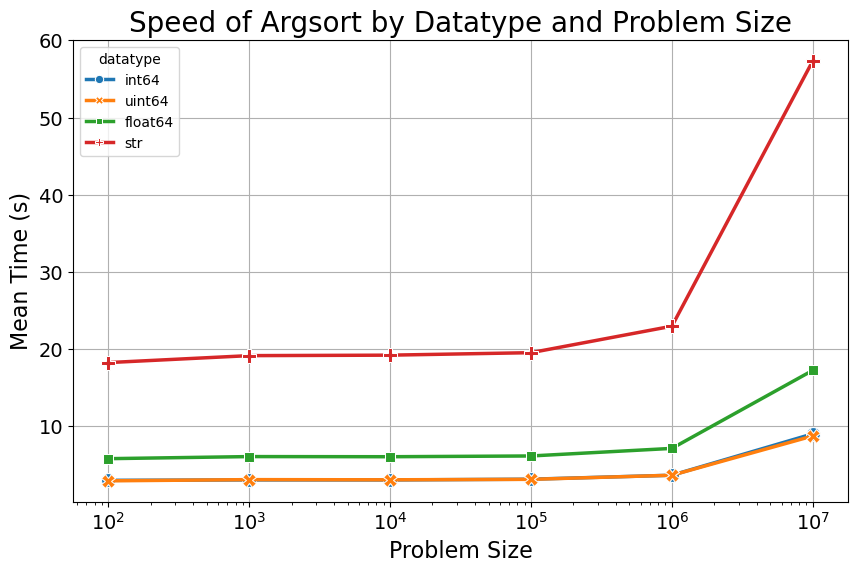

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

argsort_df = df[df['name'] == 'bench_argsort']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=argsort_df,
    x='problem_size',
    y='mean',
    hue='datatype',
    marker='o',
    linewidth=2.5,  
    markers=True,   
    style='datatype', 
    dashes=False    
)

plt.title('Speed of Argsort by Datatype and Problem Size', fontsize=20)
plt.xlabel('Problem Size', fontsize=16)
plt.ylabel('Mean Time (s)', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

lines = plt.gca().get_lines()
for line in lines:
    line.set_markersize(10) 

plt.grid(True)

plt.xscale('log', base=10)

plt.show()


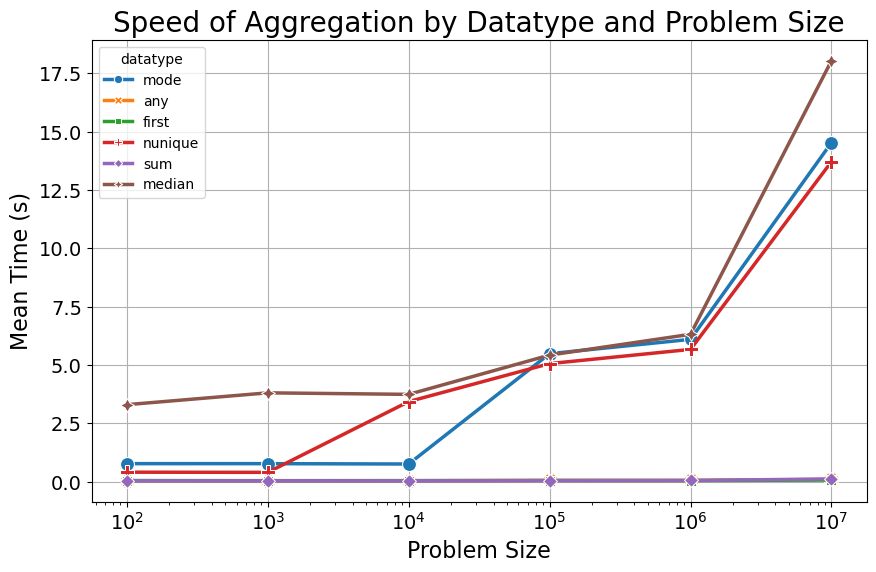

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

benchagg_df = df[df['name'] == 'bench_aggs']

# Calculate the average of the mean times for each datatype
datatype_means = benchagg_df.groupby('datatype')['mean'].mean()

# Find the 2 fastest and 2 slowest datatypes
fastest_two = datatype_means.nsmallest(3).index.tolist()
slowest_two = datatype_means.nlargest(3).index.tolist()

# Combine the lists of datatypes to keep (4 most extreme)
extreme_datatypes = fastest_two + slowest_two

# Filter the DataFrame to only include these datatypes
filtered_df = benchagg_df[benchagg_df['datatype'].isin(extreme_datatypes)]

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=filtered_df, 
    x='problem_size', 
    y='mean', 
    hue='datatype', 
    marker='o', 
    linewidth=2.5,  
    markers=True,   
    style='datatype', 
    dashes=False    
)

plt.title('Speed of Aggregation by Datatype and Problem Size', fontsize=20)
plt.xlabel('Problem Size', fontsize=16)
plt.ylabel('Mean Time (s)', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

lines = plt.gca().get_lines()
for line in lines:
    line.set_markersize(10) 
plt.grid(True)

plt.xscale('log', base=10)

plt.show()


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def human_readable_rate(rate):
    for unit in [' bits/s', 'Kbits/s', 'Mbits/s', 'Gbits/s', 'Tbits/s']:
        if rate < 1024:
            return f"{rate:.2f} {unit}"
        rate /= 1024
    return f"{rate:.2f} TB/s"


# Simplify the datatype by keeping only the part before the hyphen
df['simplified_datatype'] = df['datatype'].str.split('-').str[0]

# Remove the prefix from the operation name
df['name'] = df['name'].str.replace('bench_', '')
df['name'] = df['name'].str.replace('ak_', '')

\
# Group by the simplified datatype and operation name, then calculate the mean transfer rate
grouped_df = df.groupby(['name', 'simplified_datatype'])['transfer_rate'].mean().reset_index()
grouped_df = grouped_df[~grouped_df['simplified_datatype'].str.startswith('SortingAlgorithm')]
df = df.dropna(axis=1, how='all')  # Drops columns where all values are NaN



fastest_two = grouped_df.groupby('name')['transfer_rate'].median().nsmallest(3).index.tolist()
slowest_two = grouped_df.groupby('name')['transfer_rate'].median().nlargest(3).index.tolist()
extreme_operations = fastest_two + slowest_two

# only keep the rows with the extreme operations
filtered_df = grouped_df[grouped_df['name'].isin(extreme_operations)]

# converting the data from Gib/s to MiB/s
filtered_df['transfer_rate'] = filtered_df['transfer_rate'] * 1024**3
sorted_grouped_df = filtered_df.sort_values(by='transfer_rate', ascending=False)



/tmp/ipykernel_2936834/2782335557.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['transfer_rate'] = filtered_df['transfer_rate'] * 1024**3


/tmp/ipykernel_2936834/2895312861.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fontsize, rotation=45, horizontalalignment='right')
/tmp/ipykernel_2936834/2895312861.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)


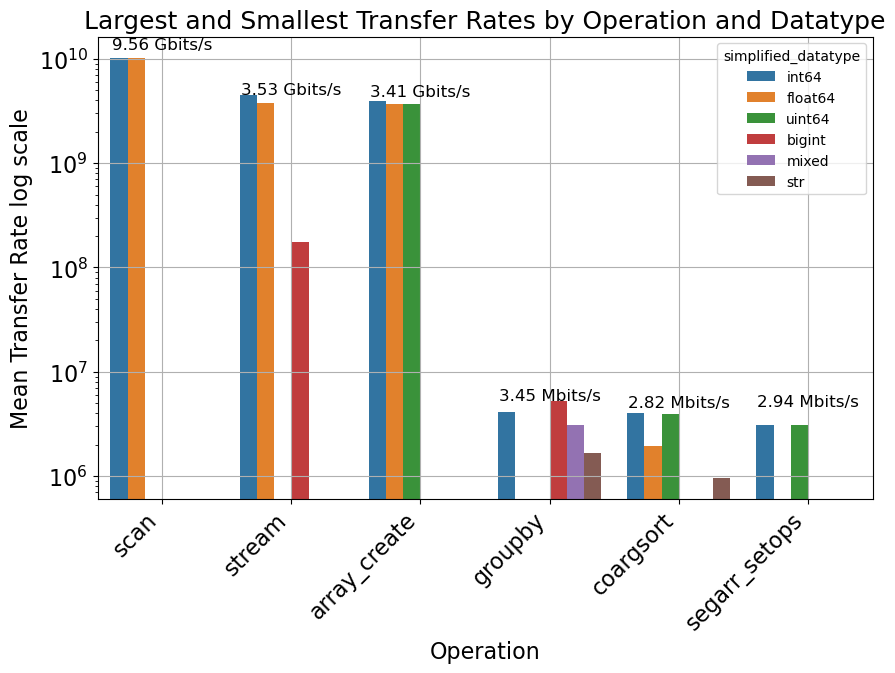

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
fontsize = 16
ax = sns.barplot(data=sorted_grouped_df, x='name', y='transfer_rate', hue='simplified_datatype',
                 hue_order=['int64', 'float64', 'uint64', 'bigint', 'mixed', 'str'])

# Calculate the median for each operation
medians = sorted_grouped_df.groupby(['name'])['transfer_rate'].median().reset_index()

# Create a list of unique operation names for positioning
unique_names = sorted_grouped_df['name'].unique().tolist()

# Position the operation names on the x-axis
for index, row in medians.iterrows():
    y_position = row['transfer_rate']
    ax.text(x_position, y_position * 1.2 + 1000000, f'{human_readable_rate(y_position)}', color='black', ha="center", fontsize=12)


plt.title('Largest and Smallest Transfer Rates by Operation and Datatype', fontsize=fontsize+2)
plt.xlabel('Operation', fontsize=fontsize)
plt.ylabel('Mean Transfer Rate log scale', fontsize=fontsize)


ax.set_xticklabels(ax.get_xticklabels(), fontsize=fontsize, rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
plt.grid(True)
plt.yscale('log')
plt.show()
